---
title: Borrowing strength across stations
subtitle: A hierarchical GEV that pools each parameter as much as the data warrant
short_title: Hierarchical pooling
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - partial pooling
  - hierarchical model
  - shrinkage
  - non-centred parameterisation
  - Neal's funnel
  - return levels
abstract: |
  Independent fits waste information; complete pooling throws away real
  variation. A hierarchical GEV is the principled middle: each station keeps its
  own parameters, tied by a shared prior whose spread τ is learned from the
  data. Fit with a non-centred NUTS parameterisation, the model pools each
  parameter exactly as much as the data warrant — leaving the location μ free
  while collapsing the noisy tail ξ onto a single shared value, and cutting the
  100-year-level uncertainty sharply. Its one blind spot, that the pooling is
  spatially agnostic, sets up the Gaussian-process field to come.
---

# Borrowing strength across stations

Notebook 04 fit every station on its own and found the tails $\xi$ — and the
100-year levels that lean on them — were dominated by sampling noise: a few
decades of annual maxima cannot pin down a tail. The opposite extreme, **complete pooling**, would
force a *single* $\xi$ on all stations, throwing away any real geographic
variation. **Partial pooling** is the principled middle ground: a **hierarchical**
model in which each station keeps its own parameters, but they are tied together
by a shared prior whose spread is *learned from the data*.

We keep the GEV likelihood and the stabilising reparameterisation from notebook
04 ($\log\sigma$, $\xi = \tfrac12\tanh\tilde\xi$), and add a **group level** on
top of each parameter:

$$
\begin{aligned}
\mu_s &\sim \mathcal N(\mu_0,\ \tau_\mu^2), &
\log\sigma_s &\sim \mathcal N(\lambda_0,\ \tau_\lambda^2), &
\tilde\xi_s &\sim \mathcal N(\xi_0,\ \tau_\xi^2),
\end{aligned}
$$

with weak hyperpriors on the group means $(\mu_0, \lambda_0, \xi_0)$ and group
spreads $(\tau_\mu, \tau_\lambda, \tau_\xi)$. The likelihood is unchanged:
$y_{s,t} \sim \mathrm{GEV}(\mu_s, \sigma_s, \xi_s)$.

All the action is in the $\tau$'s, which control **how hard** each parameter is
pooled:

* if the stations genuinely differ, the data push $\tau$ **large** and partial
  pooling $\to$ **no pooling**;
* if they don't, the data pull $\tau \to 0$ and partial pooling $\to$ **complete
  pooling**.

The model decides this *per parameter, automatically*. We will watch $\mu$ stay
free while $\xi$ collapses onto a single shared tail — precisely because notebook
04 already showed $\mu$ carries signal and $\xi$ carries almost none.

In [1]:
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while not (_p / "src" / "spatial_extremes").exists():
    if _p == _p.parent:
        raise RuntimeError("Run from inside the spatial_extremes project")
    _p = _p.parent
if str(_p / "src") not in sys.path:
    sys.path.insert(0, str(_p / "src"))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax import GeneralizedExtremeValueDistribution as GEV
from spatial_extremes import data
from spatial_extremes.viz import iberia_axes, scatter_field

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
Y = jnp.asarray(maxima)              # (S, T) — NaN where a station-year is missing
mask = ~jnp.isnan(Y)                 # observed-entry mask for the likelihood
lon, lat = stations[:, 0], stations[:, 1]
S, T = Y.shape
ybar = jnp.asarray(np.nanmean(maxima, axis=1))
ystd = jnp.asarray(np.nanstd(maxima, axis=1))
print("source:", "REAL" if is_real else "SYNTHETIC",
      "| stations", S, "| years", f"{years.min()}-{years.max()}", f"({T})")
print(f"coverage: {int(np.asarray(mask.sum(1)).min())}-"
      f"{int(np.asarray(mask.sum(1)).max())} yrs/station, "
      f"{100 * float(mask.mean()):.0f}% of the {S}×{T} grid observed")


def summarise(post, name):
    a = post[name]
    return (np.asarray(jnp.median(a, 0)),
            np.asarray(jnp.quantile(a, 0.025, 0)),
            np.asarray(jnp.quantile(a, 0.975, 0)))

source: REAL | stations 89 | years 1985-2025 (41)
coverage: 29-41 yrs/station, 97% of the 89×41 grid observed


## The no-pooling baseline (recap)

First we re-fit the independent model from notebook 04 — the stabilised
parameterisation, each station on its own — to have something to pool *against*.

In [4]:
def gev_no_pool(Y):
    with numpyro.plate("stations", S):
        mu = numpyro.sample("mu", ndist.Normal(ybar, 5.0))
        log_sigma = numpyro.sample("log_sigma", ndist.Normal(jnp.log(ystd), 0.5))
        xi_t = numpyro.sample("xi_t", ndist.Normal(0.0, 0.5))
        sigma = numpyro.deterministic("sigma", jnp.exp(log_sigma))
        xi = numpyro.deterministic("xi", 0.5 * jnp.tanh(xi_t))
    yf = jnp.where(mask, Y, ybar[:, None])     # masked likelihood (ragged records)
    lp = GEV(loc=mu[:, None], scale=sigma[:, None],
             concentration=xi[:, None]).log_prob(yf)
    numpyro.factor("obs", jnp.where(mask, lp, 0.0).sum())

mcmc_np = MCMC(NUTS(gev_no_pool, init_strategy=init_to_median,
                    target_accept_prob=0.99),
               num_warmup=1500, num_samples=1000, num_chains=1, progress_bar=False)
t0 = time.time()
mcmc_np.run(jr.PRNGKey(0), Y, extra_fields=("diverging",))
np_post = mcmc_np.get_samples()
print(f"no-pool: {time.time() - t0:.1f}s · "
      f"{int(mcmc_np.get_extra_fields()['diverging'].sum())} divergences")
np_mu, _, _ = summarise(np_post, "mu")
np_sig, _, _ = summarise(np_post, "sigma")
np_xi, np_xi_lo, np_xi_hi = summarise(np_post, "xi")

no-pool: 3.2s · 14 divergences


## The hierarchical model

Two practical points make this sample cleanly:

* **Non-centred parameterisation.** Writing $\mu_s = \mu_0 + \tau_\mu\, z_s$ with
  $z_s \sim \mathcal N(0,1)$ (and likewise for the others) decouples each station
  from the group spread it lives in. The centred form
  $\mu_s \sim \mathcal N(\mu_0, \tau_\mu^2)$ creates *Neal's funnel* — a pinched
  geometry that diverges as $\tau \to 0$, exactly the regime we expect for
  $\xi$. The non-centred form is mathematically identical but funnel-free.
* The same $\log\sigma$ / bounded-$\xi$ tricks from notebook 04 keep us off the
  GEV support edge.

So the latent draws are the standardised $z$'s and the six hyperparameters; the
per-station $(\mu_s, \sigma_s, \xi_s)$ are deterministic transforms.

In [5]:
gmean = float(np.nanmean(maxima))
log_sd0 = float(np.log(np.nanmean(np.nanstd(maxima, axis=1))))

def gev_hier(Y):
    # group level (hyperparameters)
    mu0 = numpyro.sample("mu0", ndist.Normal(gmean, 10.0))
    tau_mu = numpyro.sample("tau_mu", ndist.HalfNormal(5.0))
    lam0 = numpyro.sample("lam0", ndist.Normal(log_sd0, 0.5))
    tau_lam = numpyro.sample("tau_lam", ndist.HalfNormal(0.5))
    xi0 = numpyro.sample("xi0", ndist.Normal(0.0, 0.3))
    tau_xi = numpyro.sample("tau_xi", ndist.HalfNormal(0.3))
    # station level (non-centred)
    with numpyro.plate("stations", S):
        z_mu = numpyro.sample("z_mu", ndist.Normal(0.0, 1.0))
        z_lam = numpyro.sample("z_lam", ndist.Normal(0.0, 1.0))
        z_xi = numpyro.sample("z_xi", ndist.Normal(0.0, 1.0))
        mu = numpyro.deterministic("mu", mu0 + tau_mu * z_mu)
        sigma = numpyro.deterministic("sigma", jnp.exp(lam0 + tau_lam * z_lam))
        xi = numpyro.deterministic("xi", 0.5 * jnp.tanh(xi0 + tau_xi * z_xi))
    yf = jnp.where(mask, Y, ybar[:, None])     # masked likelihood (ragged records)
    lp = GEV(loc=mu[:, None], scale=sigma[:, None],
             concentration=xi[:, None]).log_prob(yf)
    numpyro.factor("obs", jnp.where(mask, lp, 0.0).sum())

mcmc_h = MCMC(NUTS(gev_hier, init_strategy=init_to_median, target_accept_prob=0.95),
              num_warmup=1500, num_samples=1000, num_chains=1, progress_bar=False)
t0 = time.time()
mcmc_h.run(jr.PRNGKey(0), Y, extra_fields=("diverging",))
h_post = mcmc_h.get_samples()
print(f"hierarchical: {time.time() - t0:.1f}s · "
      f"{int(mcmc_h.get_extra_fields()['diverging'].sum())} divergences")
h_mu, h_mu_lo, h_mu_hi = summarise(h_post, "mu")
h_sig, _, _ = summarise(h_post, "sigma")
h_xi, h_xi_lo, h_xi_hi = summarise(h_post, "xi")

hierarchical: 1.6s · 10 divergences


## How hard did each parameter pool?

The learned group spread $\tau$ is the dial. Compare it with the across-station
spread of the no-pool estimates: when $\tau$ is large the stations are allowed to
differ; when $\tau \approx 0$ the model has concluded they don't, and pulls every
station onto the shared value.

tau_mu   posterior median 3.118  (95% CI 2.683–3.596)
tau_lam  posterior median 0.244  (95% CI 0.204–0.290)
tau_xi   posterior median 0.158  (95% CI 0.092–0.239)


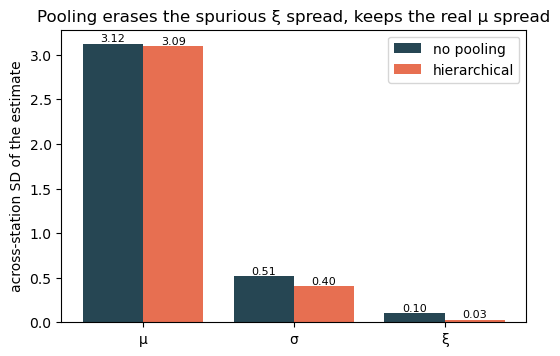

In [6]:
for name in ["tau_mu", "tau_lam", "tau_xi"]:
    q = np.quantile(np.asarray(h_post[name]), [0.025, 0.5, 0.975])
    print(f"{name:8s} posterior median {q[1]:.3f}  (95% CI {q[0]:.3f}–{q[2]:.3f})")

fig, ax = plt.subplots(figsize=(6.0, 3.8))
labels = ["μ", "σ", "ξ"]
np_sd = [np_mu.std(), np_sig.std(), np_xi.std()]
h_sd = [h_mu.std(), h_sig.std(), h_xi.std()]
x = np.arange(3)
ax.bar(x - 0.2, np_sd, 0.4, label="no pooling", color="#264653")
ax.bar(x + 0.2, h_sd, 0.4, label="hierarchical", color="#e76f51")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("across-station SD of the estimate")
ax.set_title("Pooling erases the spurious ξ spread, keeps the real μ spread")
ax.legend()
for xi_, a, b in zip(x, np_sd, h_sd):
    ax.text(xi_ - 0.2, a, f"{a:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi_ + 0.2, b, f"{b:.2f}", ha="center", va="bottom", fontsize=8)
plt.show()

## Shrinkage in action

The classic hierarchical picture: each station's estimate is pulled from its
lonely no-pool value toward the group. The distance it travels is the
**shrinkage**, and it is set by how little that station's data had to say. For
$\mu$ the lines are nearly flat — the data win. For $\xi$ they sweep together
onto a single shared tail — the group wins.

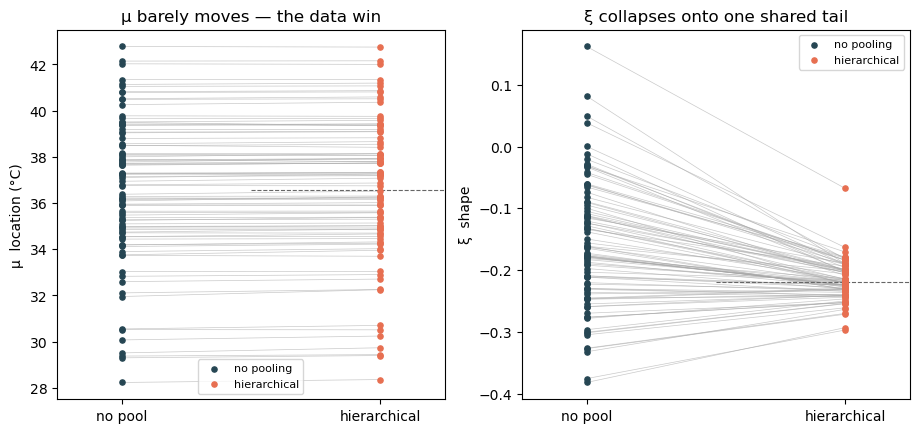

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, npv, hv, ylab, ttl in [
    (axes[0], np_mu, h_mu, "μ  location (°C)", "μ barely moves — the data win"),
    (axes[1], np_xi, h_xi, "ξ  shape", "ξ collapses onto one shared tail"),
]:
    for i in range(S):
        ax.plot([0, 1], [npv[i], hv[i]], color="0.65", lw=0.5, alpha=0.6,
                zorder=1)
    ax.scatter(np.zeros(S), npv, s=14, color="#264653", zorder=3,
               label="no pooling")
    ax.scatter(np.ones(S), hv, s=14, color="#e76f51", zorder=3,
               label="hierarchical")
    ax.axhline(hv.mean(), 0.5, 1.0, ls="--", color="0.4", lw=0.8)
    ax.set_xlim(-0.25, 1.25)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["no pool", "hierarchical"])
    ax.set_ylabel(ylab)
    ax.set_title(ttl)
    ax.legend(fontsize=8, loc="best")
plt.show()

## The pooled maps

Side by side with notebook 04: $\mu$ is essentially unchanged (it never needed
help), while the $\xi$ map has gone from noisy static to a near-uniform field —
the model's verdict that the tails are, to the resolution the data allow, the
same everywhere.

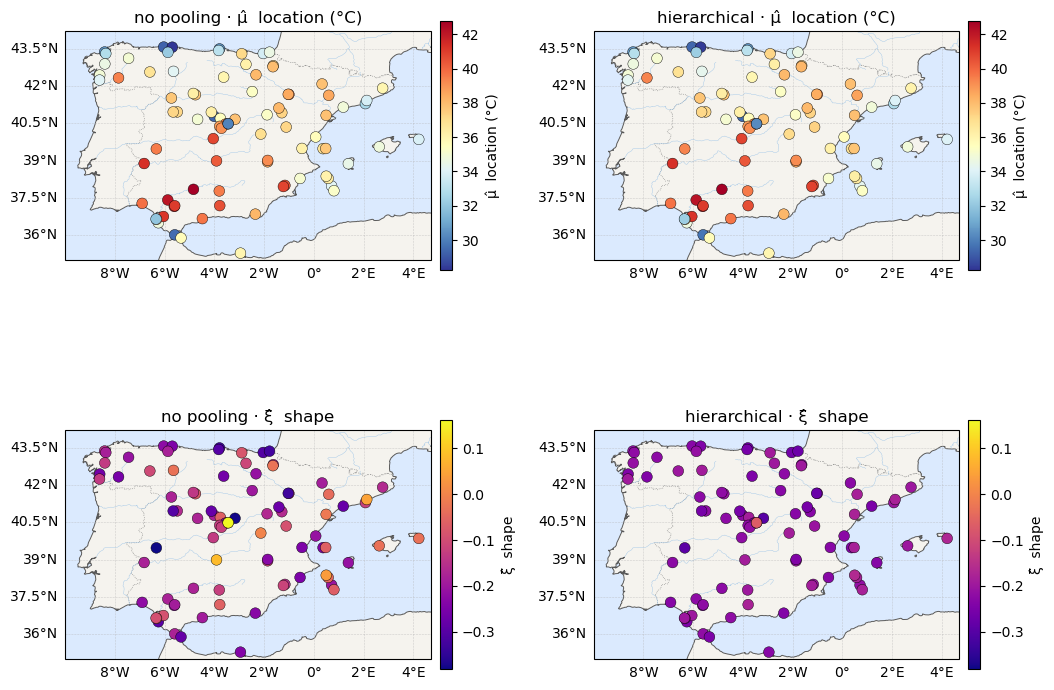

In [8]:
try:
    import cartopy.crs as ccrs
    proj = {"projection": ccrs.PlateCarree()}
except Exception:
    proj = {}

fig, axs = plt.subplots(2, 2, figsize=(12.5, 9.5), subplot_kw=proj)
for j, (np_v, h_v, label, cmap) in enumerate([
    (np_mu, h_mu, "μ̂  location (°C)", "RdYlBu_r"),
    (np_xi, h_xi, "ξ̂  shape", "plasma"),
]):
    vmin = min(np_v.min(), h_v.min())
    vmax = max(np_v.max(), h_v.max())
    for k, (vals, tag) in enumerate([(np_v, "no pooling"), (h_v, "hierarchical")]):
        ax = iberia_axes(ax=axs[j, k])
        scatter_field(ax, lon, lat, vals, label=label, cmap=cmap,
                      vmin=vmin, vmax=vmax)
        ax.set_title(f"{tag} · {label}")
plt.show()

## What the planner gets

The 100-year return level inherits the pooled tail. Compared with the
no-pooling fit, the $z_{100}$ map is smoother and — more importantly — its
**credible intervals shrink**, because each station now borrows tail information
from all the others instead of guessing from its own short record.

z100 95% CI width — no pooling : 5.8 °C avg (max 24.5)
z100 95% CI width — hierarchical: 2.7 °C avg (max 4.8)
=> average tail uncertainty cut by 54%


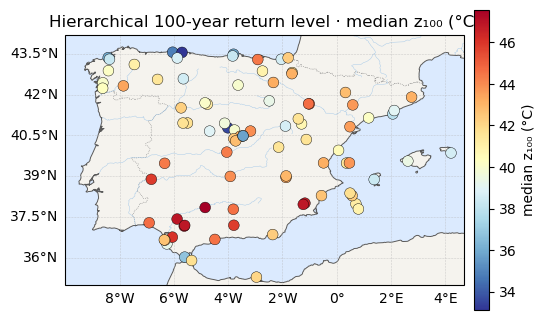

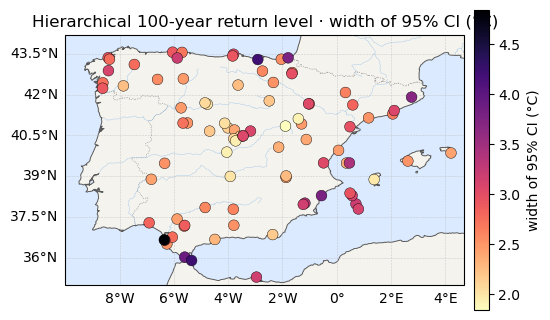

In [9]:
def rl100(post):
    RL = GEV(loc=post["mu"], scale=post["sigma"],
             concentration=post["xi"]).return_level(100.0)
    return (np.asarray(jnp.median(RL, 0)),
            np.asarray(jnp.quantile(RL, 0.975, 0) - jnp.quantile(RL, 0.025, 0)))

np_rl, np_rlw = rl100(np_post)
h_rl, h_rlw = rl100(h_post)
print(f"z100 95% CI width — no pooling : {np_rlw.mean():.1f} °C avg "
      f"(max {np_rlw.max():.1f})")
print(f"z100 95% CI width — hierarchical: {h_rlw.mean():.1f} °C avg "
      f"(max {h_rlw.max():.1f})")
print(f"=> average tail uncertainty cut by "
      f"{100 * (1 - h_rlw.mean() / np_rlw.mean()):.0f}%")

for vals, label in [(h_rl, "median z₁₀₀ (°C)"), (h_rlw, "width of 95% CI (°C)")]:
    cmap = "RdYlBu_r" if "median" in label else "magma_r"
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"Hierarchical 100-year return level · {label}")
    plt.show()

## Takeaway — and the one thing still missing

Partial pooling did exactly what notebook 04 asked for. It looked at each
parameter, measured how much real station-to-station signal there was, and
pooled accordingly — leaving $\mu$ alone, collapsing $\xi$, and tightening the
100-year levels everywhere. No knob-twiddling: the $\tau$'s learned it.

But the hierarchy is **spatially blind**. Its shared prior is *exchangeable* — it
pulls every station toward one **global** group mean, whether that station sits
in the cool northern interior or the warm Mediterranean south. Two neighbours and
two stations 800 km apart are shrunk toward the very same value. We saw $\mu$
ignore this only because its data were strong enough to resist; a parameter with
weaker signal would be pooled across geography it has no business crossing.

The fix is to make the pooling **spatial**: replace "every station shares one
mean" with "nearby stations share information, distant ones less so." That prior
over smooth spatial functions is a **Gaussian process**. **Next:** a gentle GP
primer with `pyrox`, before we let a GP field carry the GEV location $\mu(s)$
across the map.